# BCO-DMO Dataset - Final Model

Notebook by: Marisa Aubert

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import heatmap
from mlxtend.plotting import plot_decision_regions
%matplotlib inline

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, f1_score
from sklearn.impute import SimpleImputer

In [2]:
before = set(globals().keys())

In [3]:
%%capture
%run -i BCO_Final_Preprocessing_EDA.ipynb

In [4]:
after = set(globals().keys())
new_vars = after - before
#variables from exported notebook above
print(new_vars)

{'OneHotEncoder', 'unique_sites', 'X', 'precision_score', 'missing_values', 'shuffle', 'numeric_group_cols', 'X_test', 'data_dict', 'X_test_std', 'corr_abs', 'Y', 'feature_groups', '_i3', 'cm', 'preprocessing', 'X_train', 'initializers', 'df_unlabeled', 'temp_cols_to_drop', 'before', 'X_val', 'Y_test', 'Y_train', 'columns', 'os', 'Image', 'cols', 'precision_recall_curve', 'Y_val', 'cols_to_drop', 'ncols', 'splits', 'sc_x', 'weak_low', 'ax', 'df_train', 'fig', 'idx', '_i4', 'class_cols', 'df', 'n', 'X_val_std', 'df_supervised', 'corr_series', 'cols_for_plot', 'keras', 'moderate_high_low', 'recall_score', 'X_train_std', 'weak_high', 'label_binarize', 'group_name', 'sns', 'classes', 'y', 'features_encoded', 'df_bco', 'df_train_with_dummies', 'nrows', 'missing_percent', 'class_weights', 'math', 'axes', 'average_precision_score', 'col', 'location_date_dupes', 'features', 'target', 'random', 'missing_summary'}


## EDA & Pre-processing

In [6]:
pd.DataFrame(Y_train).value_counts()

0
0    11975
1     6163
2     2542
Name: count, dtype: int64

In [8]:
# Checking existing X_train variable from Preprocessing notebook
pd.DataFrame(X_train, columns=df_train.columns[1:42])

,latitude_degrees,longitude_degrees,distance_to_shore,turbidity,cyclone_frequency,depth_m,percent_cover,climsst,temperature_mean,temperature_minimum,...,tsa_frequencymax,tsa_frequencymean,tsa_dhw,tsa_dhw_standard_deviation,tsa_dhwmax,tsa_dhwmean,exposure_Sheltered,exposure_Sometimes,substrate_name_Hard Coral,substrate_name_Nutrient Indicator Algae
0,26.0847,127.7072,555.98,0.0314,67.22,4.0,NaN,262.15,298.19,291.69,...,7.25,0.5,0.0,1.28,11.51,0.36,False,False,False,False
1,-17.6411,168.1463,48.47,0.0349,57.66,5.0,16.25,298.55,300.15,295.89,...,6.0,1.0,0.0,0.92,5.77,0.34,True,False,False,True
2,-21.4917,149.8833,715.28,0.0764,48.52,NaN,NaN,297.54,297.9,292.1,...,7.0,1.0,7.99,1.56,9.85,0.54,True,False,False,False
3,-16.4994,-151.784,953.11,0.0264,48.84,15.0,50.62,301.0,300.89,297.86,...,7.0,0.0,0.0,0.79,7.36,0.24,False,False,True,False
4,25.8438,-80.0889,2990.0,0.0684,33.22,18.6,NaN,302.15,299.7,294.17,...,4.0,0.0,0.0,0.56,4.16,0.18,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20675,-4.4992,129.9375,24.61,0.0457,47.25,10.0,48.75,302.66,301.34,296.54,...,9.0,2.0,0.0,1.79,11.32,0.82,True,False,True,False
20676,10.8461,103.1745,629.51,0.1881,49.93,4.5,51.25,302.93,302.36,299.17,...,9.0,1.0,0.0,1.69,14.56,0.59,True,False,True,False
20677,1.7375,125.1519,99.72,0.0613,54.81,12.0,12.5,301.5,301.64,298.71,...,10.0,2.0,0.0,1.4,8.68,0.68,True,False,True,False
20678,12.4169,109.3044,312.79,0.0804,49.61,6.3,0.0,301.07,300.11,294.92,...,14.0,3.0,3.81,2.47,15.84,1.39,False,True,False,True


In [9]:
# Reassinging to avoid overwrite
X_train_std = X_train
X_test_std = X_test
X_val_std = X_val

In [10]:
X_test_std.shape

(6895, 41)

In [ ]:
# Reducing to only top 20 columns 
cols_to_keep = ['percent_cover', 'ssta_standard_deviation', 'longitude_degrees', 'depth_m','tsa_dhw', 'latitude_degrees', 'substrate_name_Hard Coral', 'substrate_name_Nutrient Indicator Algae',
                'tsa', 'ssta_dhw', 'tsa_mean', 'tsa_standard_deviation', 'temperature_mean', 'distance_to_shore', 'ssta_frequency', 'tsa_dhwmean', 'ssta_frequency_standard_deviation',
                'cyclone_frequency', 'ssta_dhwmean', 'temperature_minimum']

col_indices = df_train.columns.get_indexer(cols_to_keep)

col_indices = col_indices - 1
# col_indices

X_train_std = X_train_std[:,col_indices]
X_val_std = X_val_std[:,col_indices]
X_test_std = X_test_std[:,col_indices]


In [12]:
# Converting Boolean columns to floats
X_train_std = X_train_std.astype(np.float32)
X_val_std = X_val_std.astype(np.float32)
X_test_std = X_test_std.astype(np.float32)

In [ ]:
# Replacing NaN values with imputed means
imputer = SimpleImputer(strategy='mean') 
X_train_std = imputer.fit_transform(X_train_std)
X_test_std  = imputer.transform(X_test_std)

In [14]:
# Standard scaling continuous columns only (i.e., excluding one-hot encoded categorical columns)
# continuous_cols = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36]

continuous_cols = [0,1,2,3,4,5,8,9,10,11,12,13,14,15,16,17,18,19]

sc_x = StandardScaler()

X_train_std[:, continuous_cols] = sc_x.fit_transform(X_train_std[:, continuous_cols])
X_val_std[:, continuous_cols] = sc_x.fit_transform(X_val_std[:, continuous_cols])
X_test_std[:, continuous_cols] = sc_x.fit_transform(X_test_std[:, continuous_cols])

print(X_train_std.min(), X_train_std.max())

-6.662883 17.586538


In [15]:
pd.DataFrame(X_train_std, columns=cols_to_keep)

,percent_cover,ssta_standard_deviation,longitude_degrees,depth_m,tsa_dhw,latitude_degrees,substrate_name_Hard Coral,substrate_name_Nutrient Indicator Algae,tsa,ssta_dhw,tsa_mean,tsa_standard_deviation,temperature_mean,distance_to_shore,ssta_frequency,tsa_dhwmean,ssta_frequency_standard_deviation,cyclone_frequency,ssta_dhwmean,temperature_minimum
0,3.151928e-08,-0.064347,0.957416,-7.438124e-01,-0.360456,1.145363,0.0,0.0,0.783452,-0.001091,-1.658374,1.540342,-1.419755,-0.234100,-0.272422,-0.188400,0.487809,1.975383,0.162599,-1.539633
1,-1.977523e-01,-0.545403,1.343835,-5.013620e-01,-0.360456,-1.622595,0.0,1.0,-1.325030,-0.662695,0.284023,-0.395857,-0.170471,-0.272046,-1.093061,-0.205451,-0.361972,0.709402,-0.305971,0.027191
2,3.151928e-08,0.416709,1.169322,1.730093e-07,1.941013,-1.866348,0.0,0.0,-0.797909,1.706770,-1.410993,1.595269,-1.604604,-0.222189,0.219961,-0.034935,0.207148,-0.500961,-0.179532,-1.386680
3,1.835452e+00,-1.026459,-1.713279,1.923142e+00,-0.360456,-1.550322,1.0,0.0,-0.458613,-0.434101,0.677999,-0.835278,0.301213,-0.204407,0.055833,-0.290709,-1.585969,-0.458585,-0.841480,0.762094
4,3.151928e-08,-0.370474,-1.028192,2.795964e+00,-0.360456,1.130114,0.0,0.0,0.765276,-0.662695,-0.897907,0.647768,-0.457286,-0.052110,-0.600678,-0.341864,-0.658226,-2.527061,-0.335722,-0.614459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20675,1.724829e+00,-0.108080,0.978728,7.108901e-01,-0.360456,-0.790678,1.0,0.0,0.201802,1.350691,0.531403,-0.162414,0.588028,-0.273830,2.189494,0.203787,-0.556876,-0.669141,0.132848,0.269673
20676,1.872720e+00,0.285512,0.722993,-6.225873e-01,-0.360456,0.180720,1.0,0.0,-0.676732,-0.161546,0.540565,-0.643031,1.238162,-0.228602,-0.928934,0.007694,1.618252,-0.314242,0.519605,1.250803
20677,-4.195886e-01,-0.239277,0.932999,1.195791e+00,-0.360456,-0.395878,1.0,0.0,0.559275,-0.662695,1.310194,-1.054988,0.779258,-0.268214,-0.928934,0.084426,0.004447,0.331991,-0.112593,1.079190
20678,-1.159043e+00,0.810300,0.781567,-1.861765e-01,0.736990,0.280156,0.0,1.0,0.910688,0.502256,0.375645,0.373130,-0.195972,-0.252283,1.204728,0.689757,1.509106,-0.356618,1.092301,-0.334670


## Nueral Network Model

In [16]:
def build_model(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metric='accuracy'): 

    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(X_train_std.shape[1],), name='Input'))
    for hidden_layer_size in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(
            units=hidden_layer_size,
            activation=activation))
        
    model.add(tf.keras.layers.Dense(units=n_classes, 
                                    activation='softmax',
                                    name='Output'))
    if optimizer == 'SGD':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == 'Adam': 
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        raise Exception('Optimizer must be SGD or Adam')
        
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=optimizer,
                  metrics = [metric]
                  )

    return model

In [32]:
def train_and_evaluate(hidden_layer_sizes=[],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric='accuracy',
                       num_epochs=10):

  # Build model
    model = build_model(n_classes=3,
                        hidden_layer_sizes=hidden_layer_sizes,
                        activation=activation,
                        optimizer=optimizer,
                        metric=metric,
                        learning_rate=learning_rate)

  # Train model
    history = model.fit(
        x=X_train_std,
        y=Y_train,
        epochs=num_epochs,
        batch_size=32,
        validation_split=0.2,
        verbose=1)
        # class_weight=class_weight_dict)

    # Retrieve and plot metrics (accuracy and loss at each epoch)
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    fig, ax = plt.subplots(1,2, figsize = (14,4))
    
    if len(hidden_layer_sizes) == 0:
        hidden_layer_sizes = 'None'

    fig.suptitle(f'Training & Validation Metrics for FFNN Model\nHidden Layer Sizes: {hidden_layer_sizes}; Activation: {activation};  Optimizer: {optimizer}')

    ax[0].plot(train_accuracy, label='train_accuracy')
    ax[0].plot(val_accuracy, label='val_accuracy')
    ax[0].set_xticks(range(num_epochs))
    ax[0].set_xlabel('Train epochs')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()

    ax[1].plot(train_loss, label='train_loss')
    ax[1].plot(val_loss, label='val_loss')
    ax[1].set_xticks(range(num_epochs))
    ax[1].set_xlabel('Train epochs')
    ax[1].set_ylabel('Loss')
    ax[1].legend()

    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model

In [33]:
# Evaluate model results on test data and display confusion matrix
def evaluate_model(model_num, X_test, Y_test):
    model_num.evaluate(X_test, Y_test)
    Y_pred = model_num.predict(X_test)

    test_preds_labels = np.argmax(Y_pred, axis=1)
    conf_matrix = confusion_matrix(Y_test.astype(float), test_preds_labels)

    display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
    display.plot()

    plt.suptitle("Confusion Matrix for Tuned Model Results")
    plt.title("(Test Data vs. Predicted Values)")
    plt.show()

    print(classification_report(test_preds_labels, Y_test))

# Model Training

Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6117 - loss: 0.8865 - val_accuracy: 0.6951 - val_loss: 0.7678
Epoch 2/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7030 - loss: 0.7328 - val_accuracy: 0.7026 - val_loss: 0.7210
Epoch 3/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7111 - loss: 0.7014 - val_accuracy: 0.7103 - val_loss: 0.7008
Epoch 4/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7143 - loss: 0.6871 - val_accuracy: 0.7118 - val_loss: 0.6916
Epoch 5/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7154 - loss: 0.6806 - val_accuracy: 0.7113 - val_loss: 0.6871
Epoch 6/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7155 - loss: 0.6780 - val_accuracy: 0.7094 - val_loss: 0.6904
Epoch 7/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7145 - loss: 0.6777 - val_accuracy: 0.7084 - val_loss: 0.6963
Epoch 8/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7130 - loss: 0.6789 - val_accuracy: 0.

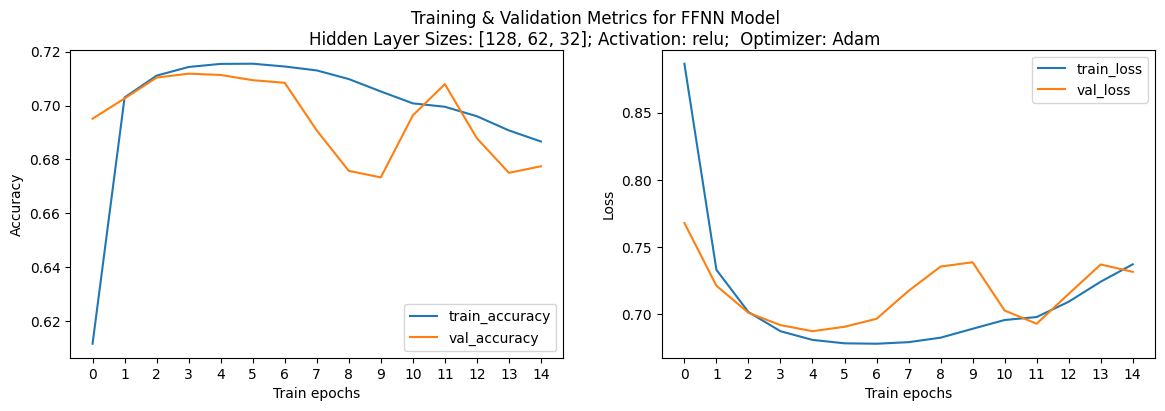

In [36]:
model_tf1 = train_and_evaluate(hidden_layer_sizes=[128,62,32],
                   activation='relu',
                   optimizer='Adam',
                   learning_rate=0.0001,
                   metric='accuracy',
                   num_epochs=15)


Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6631 - loss: 0.8113 - val_accuracy: 0.6946 - val_loss: 0.7188
Epoch 2/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7051 - loss: 0.6931 - val_accuracy: 0.6985 - val_loss: 0.7092
Epoch 3/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7009 - loss: 0.6895 - val_accuracy: 0.6985 - val_loss: 0.7079
Epoch 4/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6845 - loss: 0.7390 - val_accuracy: 0.6767 - val_loss: 0.7421
Epoch 5/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6384 - loss: 1.0035 - val_accuracy: 0.6040 - val_loss: 1.0941
Epoch 6/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6038 - loss: 1.4911 - val_accuracy: 0.5718 - val_loss: 1.4429
Epoch 7/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5607 - loss: 2.8365 - val_accuracy: 0.4971 - val_loss: 3.5135
Epoch 8/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5307 - loss: 4.7671 - val_accuracy

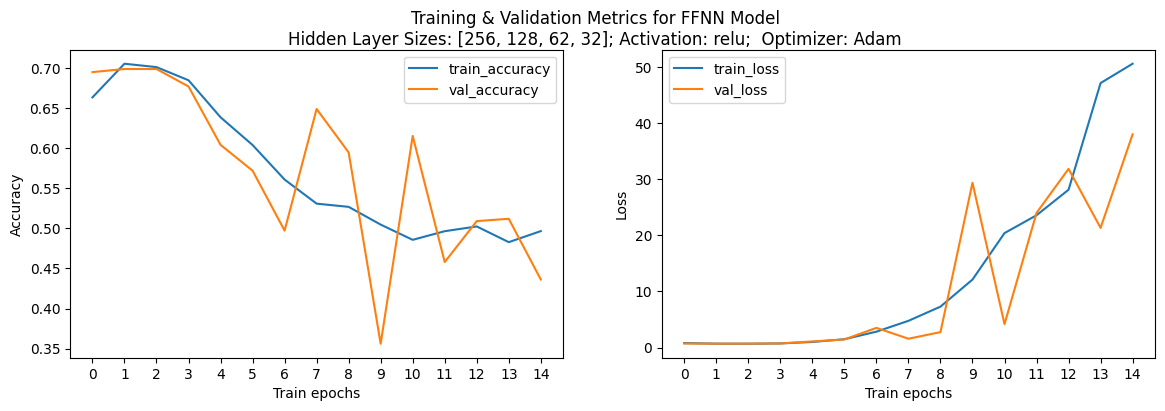

In [39]:
model_tf2 = train_and_evaluate(hidden_layer_sizes=[256,128,62,32],
                   activation='relu',
                   optimizer='Adam',
                   learning_rate=0.0001,
                   metric='accuracy',
                   num_epochs=15)

Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5847 - loss: 34.5392 - val_accuracy: 0.5230 - val_loss: 420.0589
Epoch 2/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4535 - loss: 3911.3010 - val_accuracy: 0.4229 - val_loss: 4893.7544
Epoch 3/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4432 - loss: 42013.1367 - val_accuracy: 0.5058 - val_loss: 61257.2930
Epoch 4/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4644 - loss: 119558.1719 - val_accuracy: 0.4118 - val_loss: 136866.0469
Epoch 5/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4765 - loss: 257211.9531 - val_accuracy: 0.4006 - val_loss: 333422.1250
Epoch 6/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4627 - loss: 671408.7500 - val_accuracy: 0.4886 - val_loss: 344283.6250
Epoch 7/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4863 - loss: 830360.3125 - val_accuracy: 0.5455 - val_loss: 636743.6250
Epoch 8/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 10

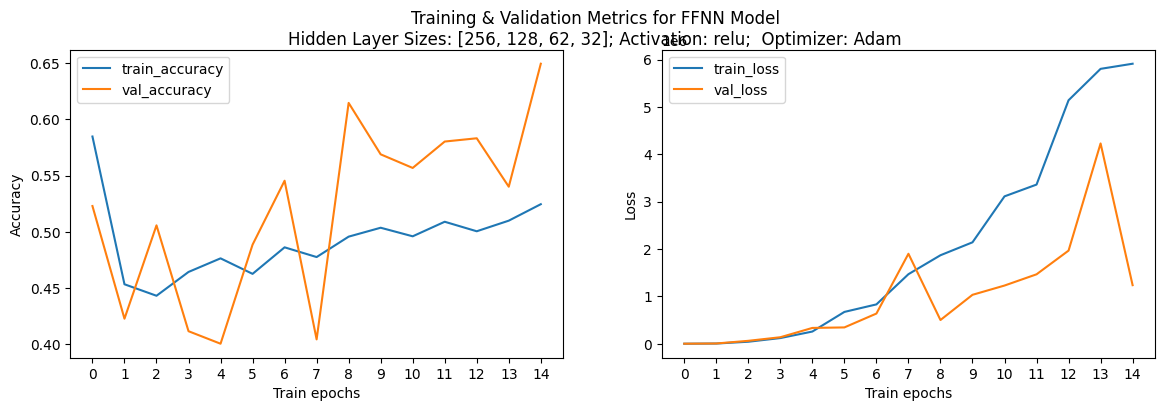

In [41]:
model_tf3 = train_and_evaluate(hidden_layer_sizes=[256,128,62,32],
                   activation='relu',
                   optimizer='Adam',
                   learning_rate=0.001,
                   metric='accuracy',
                   num_epochs=15)

Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6971 - loss: 0.6989 - val_accuracy: 0.7157 - val_loss: 0.6604
Epoch 2/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7248 - loss: 0.6384 - val_accuracy: 0.7253 - val_loss: 0.6459
Epoch 3/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7321 - loss: 0.6232 - val_accuracy: 0.7307 - val_loss: 0.6375
Epoch 4/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7366 - loss: 0.6129 - val_accuracy: 0.7343 - val_loss: 0.6310
Epoch 5/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7399 - loss: 0.6046 - val_accuracy: 0.7372 - val_loss: 0.6258
Epoch 6/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7421 - loss: 0.5974 - val_accuracy: 0.7398 - val_loss: 0.6211
Epoch 7/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7455 - loss: 0.5909 - val_accuracy: 0.7413 - val_loss: 0.6169
Epoch 8/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7480 - loss: 0.5850 - val_accuracy: 0.

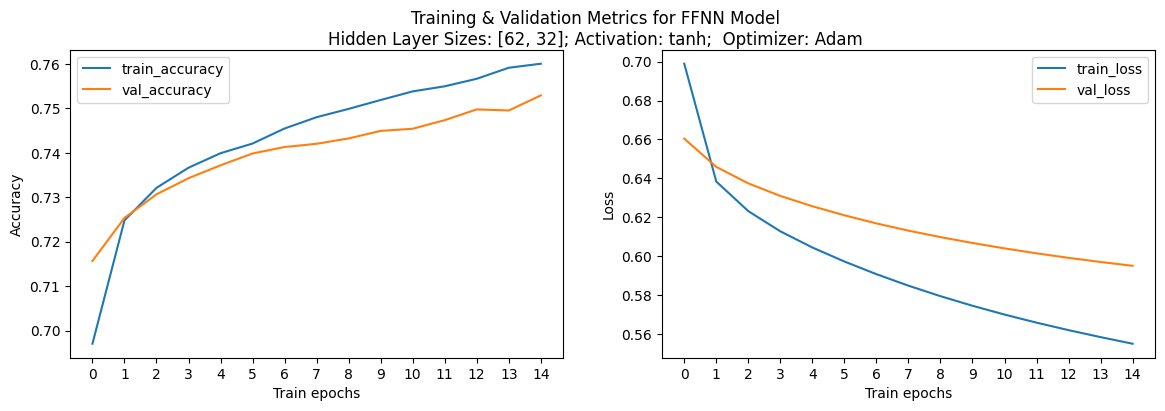

In [42]:
model_tf4 = train_and_evaluate(hidden_layer_sizes=[62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.001,
                   metric='accuracy',
                   num_epochs=15)

Epoch 1/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7050 - loss: 0.6875 - val_accuracy: 0.7207 - val_loss: 0.6589
Epoch 2/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7299 - loss: 0.6366 - val_accuracy: 0.7292 - val_loss: 0.6452
Epoch 3/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7360 - loss: 0.6221 - val_accuracy: 0.7357 - val_loss: 0.6367
Epoch 4/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7404 - loss: 0.6115 - val_accuracy: 0.7384 - val_loss: 0.6301
Epoch 5/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7434 - loss: 0.6028 - val_accuracy: 0.7408 - val_loss: 0.6244
Epoch 6/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7448 - loss: 0.5952 - val_accuracy: 0.7440 - val_loss: 0.6195
Epoch 7/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7477 - loss: 0.5886 - val_accuracy: 0.7454 - val_loss: 0.6151
Epoch 8/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7495 - loss: 0.5826 - val_accuracy: 0.

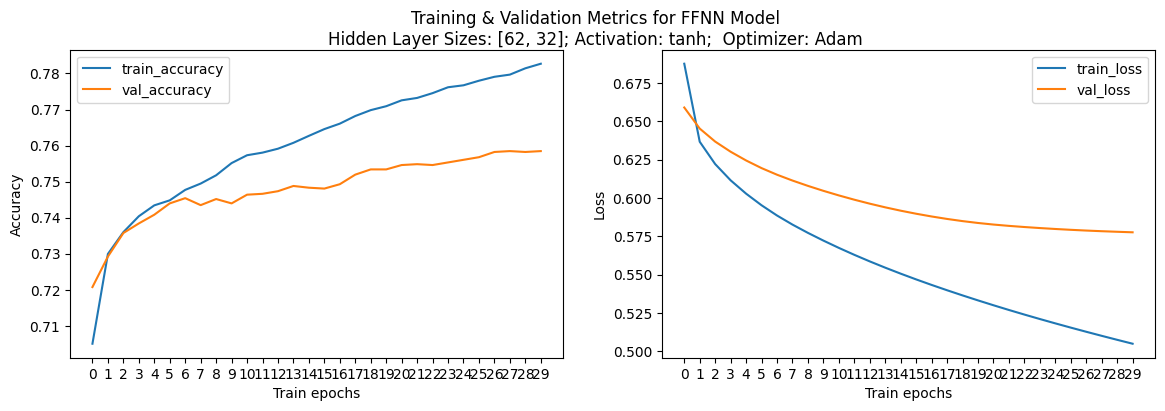

In [43]:
model_tf5 = train_and_evaluate(hidden_layer_sizes=[62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.001,
                   metric='accuracy',
                   num_epochs=30)

Epoch 1/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7134 - loss: 0.6686 - val_accuracy: 0.7215 - val_loss: 0.6534
Epoch 2/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7330 - loss: 0.6227 - val_accuracy: 0.7292 - val_loss: 0.6366
Epoch 3/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7404 - loss: 0.6061 - val_accuracy: 0.7369 - val_loss: 0.6245
Epoch 4/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7438 - loss: 0.5930 - val_accuracy: 0.7401 - val_loss: 0.6146
Epoch 5/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7492 - loss: 0.5819 - val_accuracy: 0.7454 - val_loss: 0.6071
Epoch 6/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7527 - loss: 0.5723 - val_accuracy: 0.7483 - val_loss: 0.6016
Epoch 7/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7556 - loss: 0.5637 - val_accuracy: 0.7502 - val_loss: 0.5970
Epoch 8/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7582 - loss: 0.5555 - val_accuracy: 0

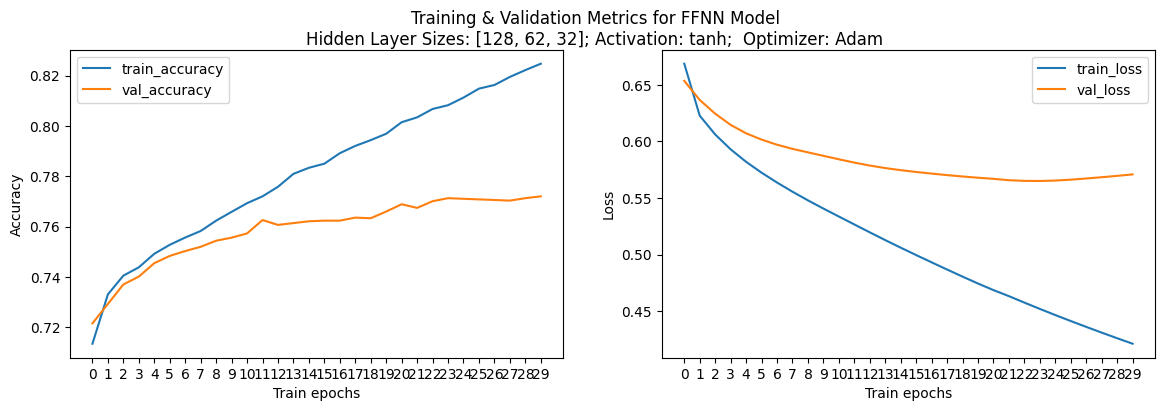

In [45]:
model_tf6 = train_and_evaluate(hidden_layer_sizes=[128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.001,
                   metric='accuracy',
                   num_epochs=30)

Epoch 1/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7151 - loss: 0.6592 - val_accuracy: 0.7319 - val_loss: 0.6462
Epoch 2/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7373 - loss: 0.6111 - val_accuracy: 0.7398 - val_loss: 0.6246
Epoch 3/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7450 - loss: 0.5932 - val_accuracy: 0.7418 - val_loss: 0.6108
Epoch 4/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7519 - loss: 0.5791 - val_accuracy: 0.7461 - val_loss: 0.6018
Epoch 5/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7570 - loss: 0.5666 - val_accuracy: 0.7534 - val_loss: 0.5955
Epoch 6/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7623 - loss: 0.5540 - val_accuracy: 0.7597 - val_loss: 0.5896
Epoch 7/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7674 - loss: 0.5416 - val_accuracy: 0.7597 - val_loss: 0.5843
Epoch 8/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7730 - loss: 0.5294 - val_accuracy: 

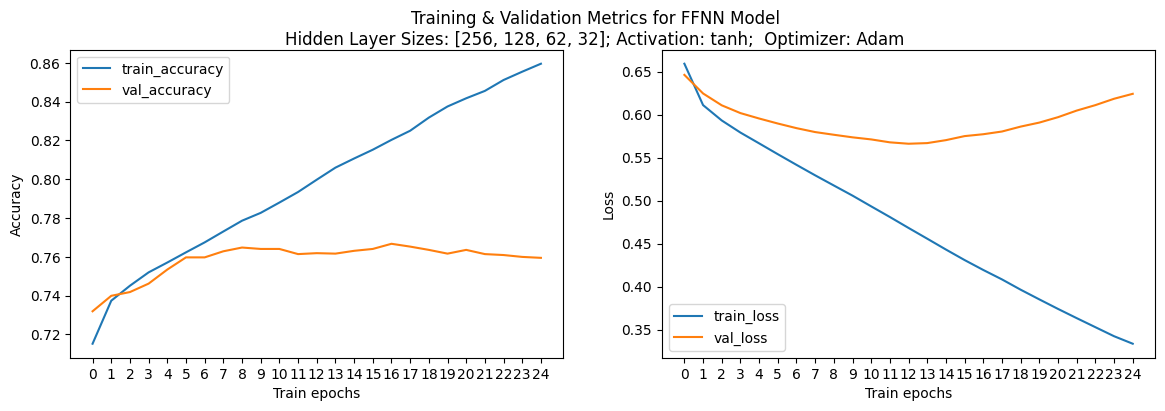

In [46]:
model_tf7 = train_and_evaluate(hidden_layer_sizes=[256,128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.001,
                   metric='accuracy',
                   num_epochs=25)

Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7142 - loss: 0.6642 - val_accuracy: 0.7174 - val_loss: 0.6430
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7341 - loss: 0.6155 - val_accuracy: 0.7319 - val_loss: 0.6226
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7434 - loss: 0.5969 - val_accuracy: 0.7319 - val_loss: 0.6089
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7467 - loss: 0.5859 - val_accuracy: 0.7432 - val_loss: 0.6027
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7508 - loss: 0.5757 - val_accuracy: 0.7425 - val_loss: 0.6015
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7570 - loss: 0.5663 - val_accuracy: 0.7478 - val_loss: 0.6014
Epoch 7/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7623 - loss: 0.5552 - val_accuracy: 0.7498 - val_loss: 0.5897
Epoch 8/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7665 - loss: 0.5481 - val_accuracy: 0.

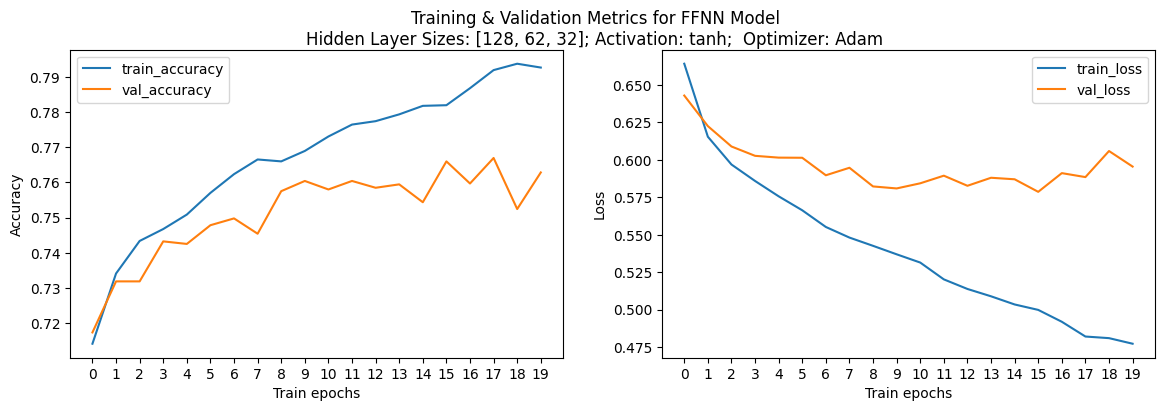

In [47]:
model_tf8 = train_and_evaluate(hidden_layer_sizes=[128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.005,
                   metric='accuracy',
                   num_epochs=20)

Epoch 1/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6381 - loss: 0.8490 - val_accuracy: 0.6852 - val_loss: 0.7513
Epoch 2/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7051 - loss: 0.7133 - val_accuracy: 0.7029 - val_loss: 0.6995
Epoch 3/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7132 - loss: 0.6788 - val_accuracy: 0.7123 - val_loss: 0.6762
Epoch 4/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7190 - loss: 0.6612 - val_accuracy: 0.7176 - val_loss: 0.6634
Epoch 5/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7230 - loss: 0.6507 - val_accuracy: 0.7217 - val_loss: 0.6557
Epoch 6/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7265 - loss: 0.6438 - val_accuracy: 0.7251 - val_loss: 0.6505
Epoch 7/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7275 - loss: 0.6389 - val_accuracy: 0.7261 - val_loss: 0.6468
Epoch 8/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7301 - loss: 0.6349 - val_accuracy: 0.

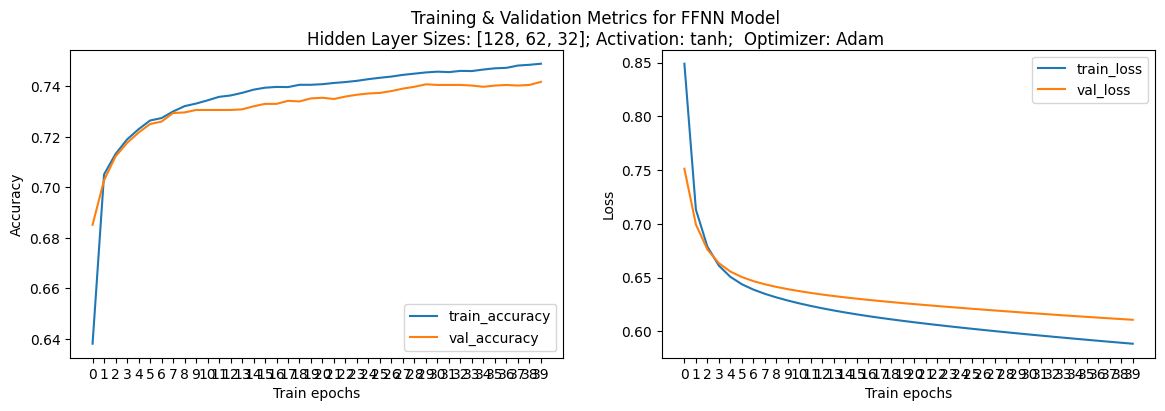

In [49]:
model_tf9 = train_and_evaluate(hidden_layer_sizes=[128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.00005,
                   metric='accuracy',
                   num_epochs=40)

Epoch 1/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6509 - loss: 0.8019 - val_accuracy: 0.6958 - val_loss: 0.7114
Epoch 2/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7105 - loss: 0.6839 - val_accuracy: 0.7067 - val_loss: 0.6779
Epoch 3/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7163 - loss: 0.6615 - val_accuracy: 0.7137 - val_loss: 0.6636
Epoch 4/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7196 - loss: 0.6508 - val_accuracy: 0.7181 - val_loss: 0.6564
Epoch 5/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7198 - loss: 0.6447 - val_accuracy: 0.7193 - val_loss: 0.6522
Epoch 6/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7225 - loss: 0.6405 - val_accuracy: 0.7215 - val_loss: 0.6492
Epoch 7/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7244 - loss: 0.6372 - val_accuracy: 0.7239 - val_loss: 0.6467
Epoch 8/40
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7258 - loss: 0.6343 - val_accuracy: 0.

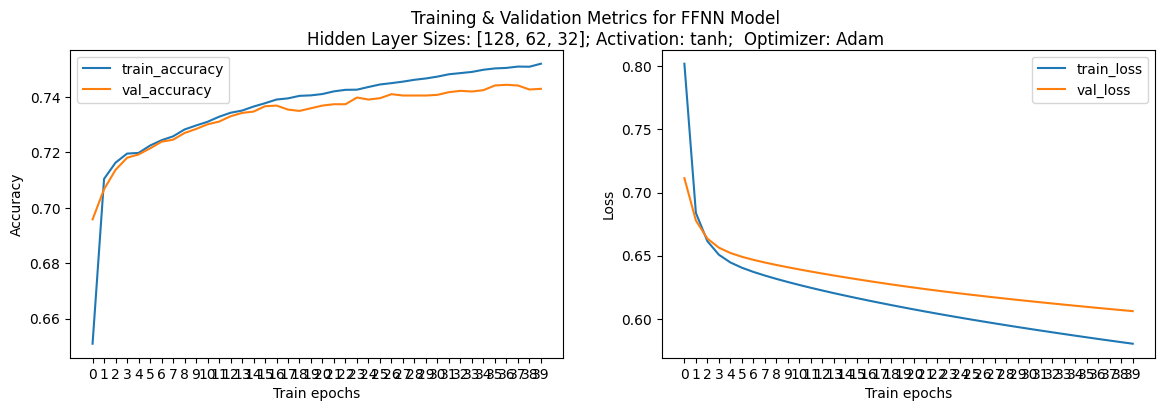

In [50]:
model_tf10 = train_and_evaluate(hidden_layer_sizes=[128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.000075,
                   metric='accuracy',
                   num_epochs=40)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7176 - loss: 0.6582 - val_accuracy: 0.7280 - val_loss: 0.6406
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7368 - loss: 0.6095 - val_accuracy: 0.7350 - val_loss: 0.6203
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7463 - loss: 0.5885 - val_accuracy: 0.7386 - val_loss: 0.6083
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7556 - loss: 0.5712 - val_accuracy: 0.7481 - val_loss: 0.6038
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7621 - loss: 0.5545 - val_accuracy: 0.7483 - val_loss: 0.5997
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7698 - loss: 0.5369 - val_accuracy: 0.7527 - val_loss: 0.5856
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7759 - loss: 0.5225 - val_accuracy: 0.7558 - val_loss: 0.5798
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7832 - loss: 0.5041 - val_accu

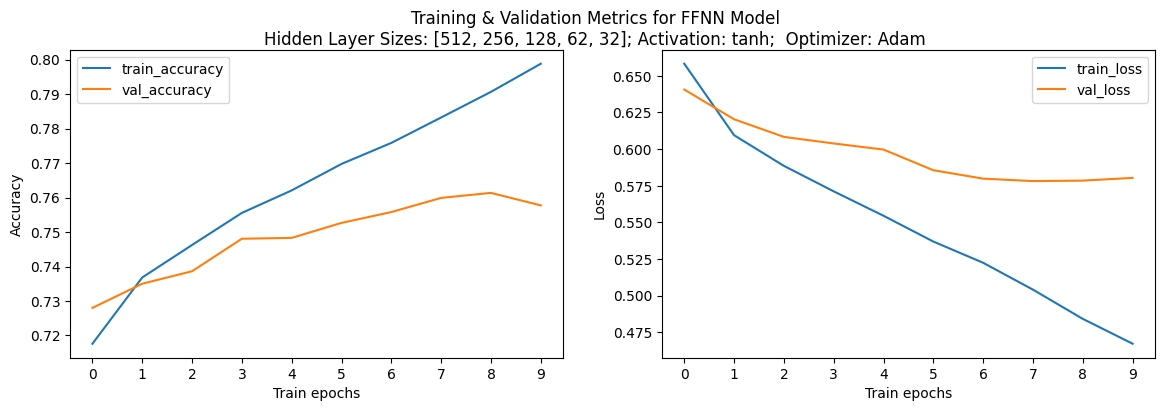

In [54]:
model_tf11 = train_and_evaluate(hidden_layer_sizes=[512,256,128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.001,
                   metric='accuracy',
                   num_epochs=10)

Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7120 - loss: 0.6747 - val_accuracy: 0.7258 - val_loss: 0.6436
Epoch 2/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7267 - loss: 0.6296 - val_accuracy: 0.7241 - val_loss: 0.6347
Epoch 3/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7380 - loss: 0.6115 - val_accuracy: 0.7391 - val_loss: 0.6156
Epoch 4/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7416 - loss: 0.6010 - val_accuracy: 0.7362 - val_loss: 0.6191
Epoch 5/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7483 - loss: 0.5865 - val_accuracy: 0.7316 - val_loss: 0.6109
Epoch 6/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7539 - loss: 0.5729 - val_accuracy: 0.7459 - val_loss: 0.6001
Epoch 7/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7599 - loss: 0.5594 - val_accuracy: 0.7444 - val_loss: 0.5979
Epoch 8/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7622 - loss: 0.5495 - val_accu

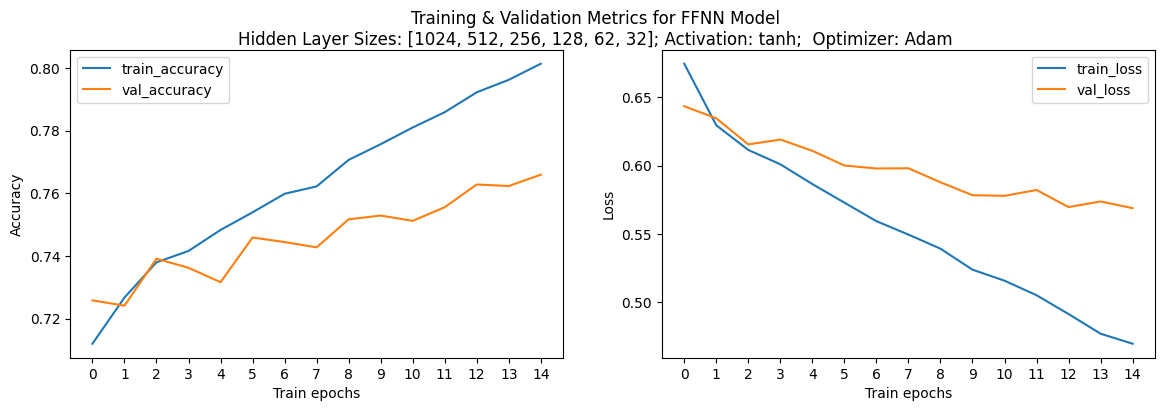

In [55]:
model_tf12 = train_and_evaluate(hidden_layer_sizes=[1024,512,256,128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.001,
                   metric='accuracy',
                   num_epochs=15)

Epoch 1/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7126 - loss: 0.6730 - val_accuracy: 0.7232 - val_loss: 0.6558
Epoch 2/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7315 - loss: 0.6223 - val_accuracy: 0.7304 - val_loss: 0.6346
Epoch 3/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7399 - loss: 0.6062 - val_accuracy: 0.7377 - val_loss: 0.6206
Epoch 4/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7452 - loss: 0.5945 - val_accuracy: 0.7420 - val_loss: 0.6108
Epoch 5/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7487 - loss: 0.5851 - val_accuracy: 0.7464 - val_loss: 0.6034
Epoch 6/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7524 - loss: 0.5768 - val_accuracy: 0.7495 - val_loss: 0.5971
Epoch 7/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7563 - loss: 0.5690 - val_accuracy: 0.7510 - val_loss: 0.5913
Epoch 8/30
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7598 - loss: 0.5614 - val_accu

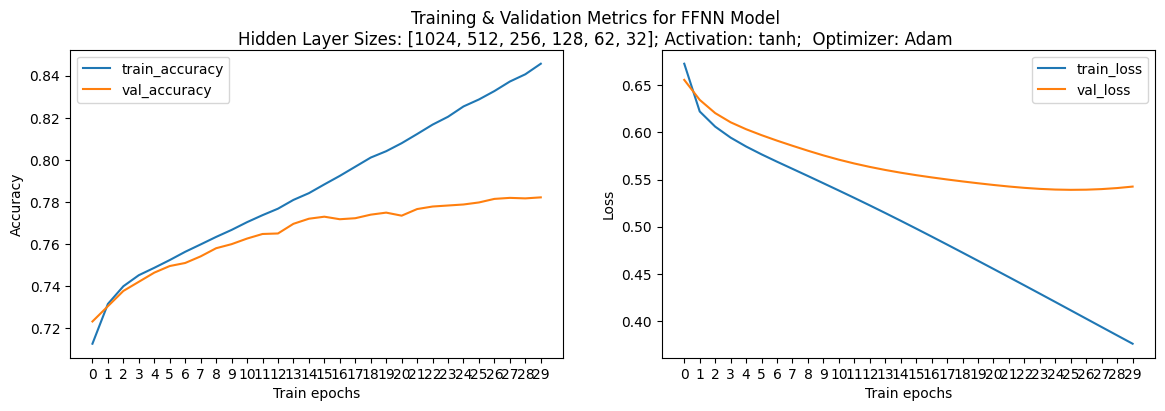

In [56]:
model_tf13 = train_and_evaluate(hidden_layer_sizes=[1024,512,256,128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.0001,
                   metric='accuracy',
                   num_epochs=30)

Epoch 1/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.7199 - loss: 0.6555 - val_accuracy: 0.7256 - val_loss: 0.6442
Epoch 2/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7350 - loss: 0.6127 - val_accuracy: 0.7406 - val_loss: 0.6226
Epoch 3/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.7444 - loss: 0.5963 - val_accuracy: 0.7444 - val_loss: 0.6089
Epoch 4/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.7485 - loss: 0.5836 - val_accuracy: 0.7469 - val_loss: 0.5998
Epoch 5/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7544 - loss: 0.5725 - val_accuracy: 0.7505 - val_loss: 0.5922
Epoch 6/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.7588 - loss: 0.5619 - val_accuracy: 0.7541 - val_loss: 0.5854
Epoch 7/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7635 - loss: 0.5517 - val_accuracy: 0.7577 - val_loss: 0.5791
Epoch 8/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7690 - loss: 0.5416 - 

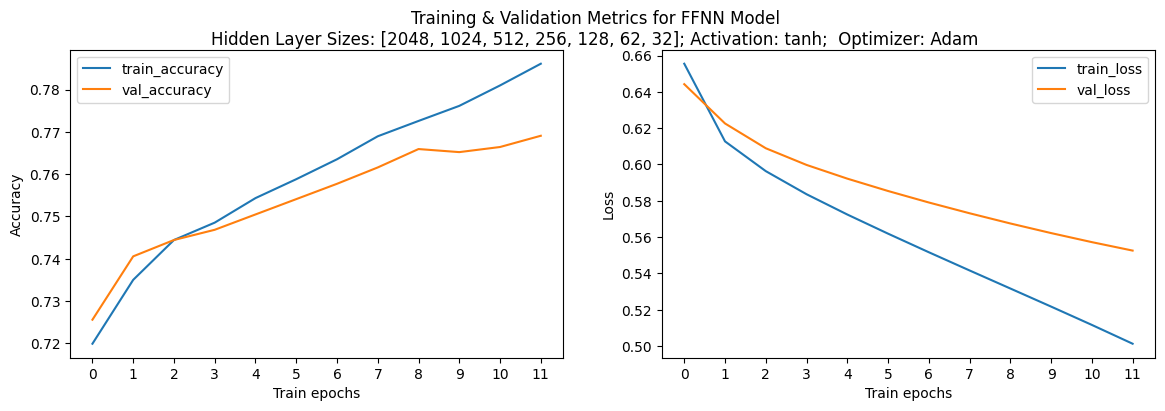

In [ ]:
model_tf14 = train_and_evaluate(hidden_layer_sizes=[2048,1024,512,256,128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.000075,
                   metric='accuracy',
                   num_epochs=12)

Epoch 1/50
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6997 - loss: 0.6963 - val_accuracy: 0.7227 - val_loss: 0.6566
Epoch 2/50
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7296 - loss: 0.6319 - val_accuracy: 0.7326 - val_loss: 0.6419
Epoch 3/50
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7348 - loss: 0.6173 - val_accuracy: 0.7348 - val_loss: 0.6335
Epoch 4/50
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7379 - loss: 0.6074 - val_accuracy: 0.7336 - val_loss: 0.6267
Epoch 5/50
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7419 - loss: 0.5993 - val_accuracy: 0.7336 - val_loss: 0.6206
Epoch 6/50
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7441 - loss: 0.5921 - val_accuracy: 0.7374 - val_loss: 0.6151
Epoch 7/50
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7482 - loss: 0.5856 - val_accuracy: 0.7406 - val_loss: 0.6103
Epoch 8/50
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7506 - loss: 0.5796 - val_accuracy: 0.

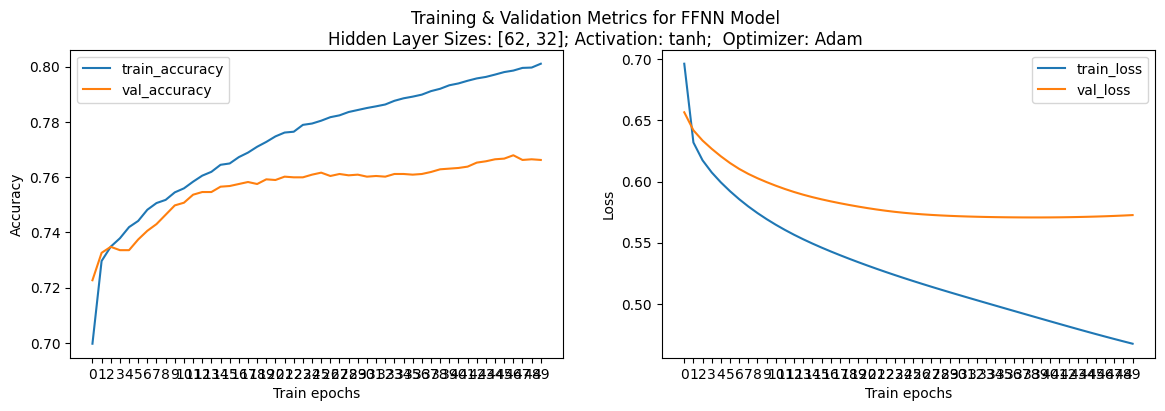

In [58]:
model_tf15 = train_and_evaluate(hidden_layer_sizes=[62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.001,
                   metric='accuracy',
                   num_epochs=50)

Epoch 1/16
517/517 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7123 - loss: 0.6677 - val_accuracy: 0.7215 - val_loss: 0.6503
Epoch 2/16
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7319 - loss: 0.6229 - val_accuracy: 0.7384 - val_loss: 0.6320
Epoch 3/16
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7404 - loss: 0.6074 - val_accuracy: 0.7425 - val_loss: 0.6203
Epoch 4/16
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7443 - loss: 0.5960 - val_accuracy: 0.7442 - val_loss: 0.6114
Epoch 5/16
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7485 - loss: 0.5865 - val_accuracy: 0.7466 - val_loss: 0.6042
Epoch 6/16
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7536 - loss: 0.5781 - val_accuracy: 0.7517 - val_loss: 0.5979
Epoch 7/16
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7571 - loss: 0.5701 - val_accuracy: 0.7544 - val_loss: 0.5920
Epoch 8/16
517/517 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7602 - loss: 0.5623 - val_accu

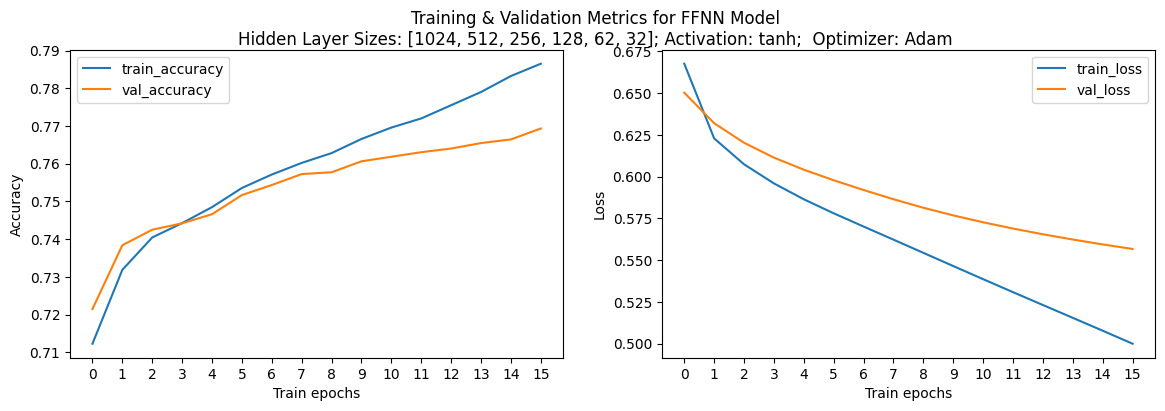

In [67]:
model_tf16 = train_and_evaluate(hidden_layer_sizes=[1024,512,256,128,62,32],
                   activation='tanh',
                   optimizer='Adam',
                   learning_rate=0.0001,
                   metric='accuracy',
                   num_epochs=16)

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7649 - loss: 0.5512
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


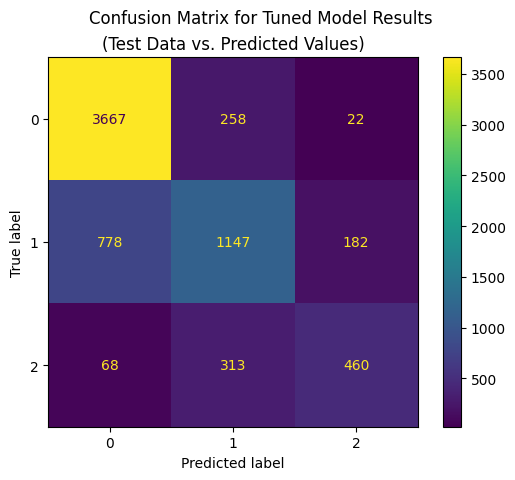

              precision    recall  f1-score   support

           0       0.93      0.81      0.87      4513
           1       0.54      0.67      0.60      1718
           2       0.55      0.69      0.61       664

    accuracy                           0.76      6895
   macro avg       0.67      0.72      0.69      6895
weighted avg       0.80      0.76      0.78      6895



In [68]:
evaluate_model(model_tf16, X_test_std, Y_test)

# Ablation Study Results

Model | Hidden layer sizes | Activation| Optimizer | Learning rate | Epochs | Training accuracy| Validation accuracy
-|-|-|-|-|-|-|-
 model_tf1 | [128,62,32] | relu | Adam |0.0001| 15 | 0.6867 | 0.6775 
 model_tf2 | [256,128,62,32] | relu | Adam |0.0001| 15 | 0.4965 | 0.4362
 model_tf3 | [512,256,128,62,32] | relu | Adam |0.001| 15 | 0.5246 | 0.6494
 model_tf4 | [62,32] | tanh | Adam |0.001| 15 | 0.7600 | 0.7529
 model_tf5 | [62,32] | tanh | Adam |0.001| 30 | 0.7827 | 0.7585
 model_tf6 | [128,62,32] | tanh | Adam |0.001| 30 | 0.8248 | 0.7720 
 model_tf7 | [256,128,62,32] | tanh | Adam |0.001| 25 | 0.8596 | 0.7594
 model_tf8 | [128,62,32] | tanh | Adam |0.005| 20 | 0.7926 | 0.7628 
 model_tf9 | [128,62,32] | tanh | Adam |0.00005| 40 | 0.7490 | 0.7418
 model_tf10 | [128,62,32] | tanh | Adam |0.000075| 40 | 0.7521 | 0.7439
 model_tf11 | [512,256,128,62,32] | tanh | Adam |0.001| 10 | 0.7988 | 0.7577
 model_tf12 | [1024,512,256,128,62,32] | tanh | Adam |0.001| 15 | 0.8014 | 0.7660
 model_tf13 | [1024,512,256,128,62,32] | tanh | Adam |0.0001| 30 | 0.8457 | 0.7822
 model_tf14 | [2048,1024,512,256,128,62,32] | tanh | Adam |0.000075| 12 | 0.7861 | 0.7691
 model_tf15 | [62,32] | tanh | Adam |0.001| 50 | 0.8010 | 0.7662
 model_tf16 | [1024,512,256,128,62,32] | tanh | Adam |0.0001| 16 | 0.7865 | 0.7693


